# LoRA: How Can a Single RTX 4090 Fine-Tune a 70B Model?

> **Background**: you have a 70B-parameter LLM and want to fine-tune it on ~1000 dialogue examples.
> Full fine-tuning would require huge VRAM: weights + gradients + optimizer states (often multiple A100s).
> LoRA claims: you can do it on a single consumer GPU.
>
> Goal for this part: **understand LoRA from scratch (low-rank matrix updates), implement a `LoraLinear`, plug it into MiniGPT, and verify that it actually learns.**


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

torch.manual_seed(42)

### 1. Why is full fine-tuning so expensive? One table

Assume single-GPU fine-tuning VRAM is consumed by:

| Component | Rough formula | LLaMA-7B | LLaMA-70B |
|:---|:---|:---:|:---:|
| Weights (FP16) | `2 × N_bytes` | 14 GB | 140 GB |
| Adam optimizer states | `12 × N_bytes` | 84 GB | 840 GB |
| Gradients | `2 × N_bytes` | 14 GB | 140 GB |
| Activations | depends on batch | ~8 GB | ~20 GB |
| **Total (full FT)** | | **~120 GB** | **~1140 GB** |
| **Total (LoRA, r=16)** | mostly optimizer states for LoRA params | **~15 GB** | **~145 GB** |

Key idea: LoRA **does not update the original weights**.
The base weights are frozen; we only train small side matrices.

### 2. Intuition: why is the weight update low-rank?

Analogy:
- full fine-tuning = repaint the whole painting (change every stroke)
- LoRA = add a thin translucent overlay and adjust a few key color directions (low-rank change)

Math intuition:
A pretrained model already encodes general language patterns.
To adapt to a new task you do not need to rewrite everything; you move along a small number of important directions.
So the update matrix `ΔW` has **rank r** where `r << d`.

What does "low rank" mean?
A `d×d` matrix with full rank (d=4096) has ~16M degrees of freedom.
But a rank-16 update can be factorized:

```
ΔW (4096×4096) = A (4096×16) × B (16×4096)
params: 16M -> ~131k  (about 1/128)
```


### 3. Hand-compute: what does LoRA forward actually do?

Remember the core formula:

$$h = Wx + rac{lpha}{r} \cdot A B x$$

Where:
- `W`: original weight (frozen)
- `A`: small matrix `(d_out, r)` (trainable)
- `B`: small matrix `(r, d_in)` (trainable, initialized to 0)
- `α`: scaling factor
- `r`: rank (often 8/16/32/64)

Why initialize `B=0`?
So at the start `ΔW = A B = 0` and the model behaves exactly like the base model.
The adaptation is introduced gradually.

Next we compute a tiny example by hand: `d_in=4, d_out=4, r=2`.


In [2]:
# ============================================================
# manual LoRA：d_in=4, d_out=4, r=2
# ============================================================
torch.manual_seed(42)

d_in, d_out, r = 4, 4, 2
alpha = 2  # scaling factor

# base weight( ,frozen)
W = torch.randn(d_out, d_in)
print("base weight W (4x4):")
print(W)
print(f" #params: {W.numel()}")

# LoRA 
A = torch.randn(d_out, r) * 0.02   #  
B = torch.zeros(r, d_in)            # ← Key：B 0！
print(f"\nA (d_out x r = 4x2):")
print(A)
print(f"B (r x d_in = 2x4), 0:")
print(B)
print(f" A : {A.numel()}, B : {B.numel()}, : {A.numel() + B.numel()}")
print(f" compression ratio: {W.numel() / (A.numel() + B.numel()):.1f}x")

# input x
x = torch.tensor([1.0, 0.5, -0.5, -1.0])
print(f"\ninput x (4,): {x}")

# ============================================================
#  
# ============================================================
#  output( LoRA)
h_original = W @ x
print(f"\n output Wx: {h_original}")

# LoRA side path
h_lora = B @ x     # Step 1: (r, d_in) @ (d_in,) -> (r,) 
h_lora = A @ h_lora  # Step 2: (d_out, r) @ (r,) -> (d_out,) 
scaling = alpha / r
delta = h_lora * scaling
print(f"\nLoRA side path :")
print(f"  Step 1 - Bx (r={r},): {h_lora}")
print(f"  Step 2 - A(Bx) (d_out={d_out},): {h_lora}")
print(f" scaling factor alpha/r: {scaling}")
print(f"  delta = (alpha/r) * A(Bx): {delta}")

# ★ output： output + LoRA 
h_final = h_original + delta
print(f"\n output = Wx + (alpha/r)*ABx: {h_final}")

# ★ verify：B=0 ,delta=0,output = output
print(f"\nverify B=0 delta 0: {(h_final == h_original).all().item()}")
print("(So at the start,the model behavior is unchanged！)")

base weight W (4x4):
tensor([[ 1.9269,  1.4873,  0.9007, -2.1055],
        [ 0.6784, -1.2345, -0.0431, -1.6047],
        [-0.7521,  1.6487, -0.3925, -1.4036],
        [-0.7279, -0.5594, -0.7688,  0.7624]])
 #params: 16

A (d_out x r = 4x2):
tensor([[ 0.0092,  0.0053],
        [ 0.0107,  0.0162],
        [ 0.0222, -0.0338],
        [-0.0198,  0.0192]])
B (r x d_in = 2x4), 0:
tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.]])
 A : 8, B : 8, : 16
 compression ratio: 1.0x

input x (4,): tensor([ 1.0000,  0.5000, -0.5000, -1.0000])

 output Wx: tensor([ 4.3257,  1.6873,  1.6721, -1.3856])

LoRA side path :
  Step 1 - Bx (r=2,): tensor([0., 0., 0., 0.])
  Step 2 - A(Bx) (d_out=4,): tensor([0., 0., 0., 0.])
 scaling factor alpha/r: 1.0
  delta = (alpha/r) * A(Bx): tensor([0., 0., 0., 0.])

 output = Wx + (alpha/r)*ABx: tensor([ 4.3257,  1.6873,  1.6721, -1.3856])

verify B=0 delta 0: True
(So at the start,the model behavior is unchanged！)


### 4. Code: `LoraLinear` (a wrapper around `nn.Linear`)

We'll implement a `LoraLinear` that behaves like `nn.Linear` but adds a LoRA side path.


In [3]:
# ============================================================
# LoraLinear：wrap nn.Linear, LoRA side path
# ============================================================
class LoraLinear(nn.Module):
    """ equivalent to: y = Wx + (alpha/r) * A(Bx) - W: base weight(requires_grad=False,frozen) - A: (out_features, r) ( ) - B: (r, in_features) ( ) """
    def __init__(self, linear: nn.Linear, r: int, alpha: int = None):
        super().__init__()
        #  
        self.linear = linear
        self.in_features = linear.in_features
        self.out_features = linear.out_features
        self.r = r
        self.alpha = alpha if alpha is not None else r

        # frozenbase weight
        self.linear.weight.requires_grad = False
        if self.linear.bias is not None:
            self.linear.bias.requires_grad = False

        # LoRA ：A ,B 0
        # A: (out_features, r)  B: (r, in_features)
        self.lora_A = nn.Parameter(torch.randn(self.out_features, r) * 0.02)
        self.lora_B = nn.Parameter(torch.zeros(r, self.in_features))
        self.scaling = self.alpha / self.r

    def forward(self, x):
        # Step 1: output(frozen , )
        original = self.linear(x)  # x @ W^T + bias
        # Step 2: LoRA side path -> dropout ,r 
        #  : x @ (lora_A @ lora_B)^T * scaling, (B^T @ A^T @ x^T)^T
        # equivalent to: (x @ lora_B^T) @ lora_A^T * scaling
        lora_out = (x @ self.lora_B.T) @ self.lora_A.T * self.scaling
        return original + lora_out

    @property
    def weight(self):
        """ : W + (alpha/r) * AB"""
        with torch.no_grad():
            delta_W = self.lora_A @ self.lora_B * self.scaling
            return self.linear.weight + delta_W


#  
torch.manual_seed(42)
linear = nn.Linear(4, 4, bias=False)
linear.weight.data = torch.randn(4, 4)  #  

lora_layer = LoraLinear(linear, r=2, alpha=2)

print("=== LoraLinear ===")
print(f" base weight requires_grad: {lora_layer.linear.weight.requires_grad}")
print(f"  lora_A requires_grad: {lora_layer.lora_A.requires_grad}")
print(f"  lora_B requires_grad: {lora_layer.lora_B.requires_grad}")

#  
total = sum(p.numel() for p in lora_layer.parameters())
trainable = sum(p.numel() for p in lora_layer.parameters() if p.requires_grad)
print(f"\n : {total}, : {trainable} ({100*trainable/total:.1f}%)")

#  
x = torch.tensor([[1.0, 0.5, -0.5, -1.0]])
y = lora_layer(x)
print(f"\n input x: {x.tolist()}")
print(f" output y: {y.tolist()}")

=== LoraLinear ===
 base weight requires_grad: False
  lora_A requires_grad: True
  lora_B requires_grad: True

 : 32, : 16 (50.0%)

 input x: [[1.0, 0.5, -0.5, -1.0]]
 output y: [[1.3716278076171875, -2.2999930381774902, 0.28736478090286255, -0.944815456867218]]


### 5. Toy verification: can LoRA learn almost as well as full fine-tuning?

We create a simple regression task: learn a `4 -> 4` linear map from 30 data points.
Compare:
- full fine-tuning (update all parameters)
- LoRA (r=2)
- no training (baseline)


In [4]:
# ============================================================
#  ： 
# ============================================================
torch.manual_seed(42)

#  ： y = X @ W_target
d = 4
W_target = torch.tensor([
    [ 0.5, -0.3,  0.8, -0.2],
    [-0.4,  0.6, -0.1,  0.7],
    [ 0.3, -0.5, -0.6,  0.4],
    [-0.7,  0.2,  0.5, -0.8],
])

N = 30
X_train = torch.randn(N, d)
y_train = X_train @ W_target + 0.05 * torch.randn(N, d)  #  

print(f" : X ({N}x{d}), y ({N}x{d})")
print(f" W_target:\n{W_target}")

# ============================================================
#  ： 
# ============================================================
torch.manual_seed(100)
W_full = nn.Linear(d, d, bias=False)
W_full.weight.data = torch.randn(d, d)  #  ( )

print(f"\n=== ： ===")
print(f" :\n{W_full.weight.data}")
print(f" : {sum(p.numel() for p in W_full.parameters())}")

opt_full = torch.optim.Adam(W_full.parameters(), lr=0.01)
losses_full = []
for epoch in range(200):
    opt_full.zero_grad()
    loss = F.mse_loss(W_full(X_train), y_train)
    loss.backward()
    opt_full.step()
    losses_full.append(loss.item())

print(f" loss: {losses_full[-1]:.6f}")

# ============================================================
#  ：LoRA (r=2)
# ============================================================
torch.manual_seed(100)  #  
W_base = nn.Linear(d, d, bias=False)
W_base.weight.data = torch.randn(d, d)  #  

# wrap LoRA
lora_model = LoraLinear(W_base, r=2, alpha=4)

print(f"\n=== ：LoRA (r=2) ===")
print(f"base weight(frozen):\n{lora_model.linear.weight.data}")
print(f" : {sum(p.numel() for p in lora_model.parameters() if p.requires_grad)}")

opt_lora = torch.optim.Adam(lora_model.parameters(), lr=0.01)
losses_lora = []
for epoch in range(200):
    opt_lora.zero_grad()
    loss = F.mse_loss(lora_model(X_train), y_train)
    loss.backward()
    opt_lora.step()
    losses_lora.append(loss.item())

print(f" loss: {losses_lora[-1]:.6f}")

# ============================================================
#  
# ============================================================
print(f"\n=== ===")
print(f" loss: {losses_full[-1]:.6f} ( {d*d} )")
print(f"  LoRA r=2  loss: {losses_lora[-1]:.6f} ( {2*d*2} )")

#  LoRA 
with torch.no_grad():
    learned_W = lora_model.weight  #  
    print(f"\n LoRA :\n{learned_W}")
    print(f" :\n{W_target}")
    print(f" vs MSE: {F.mse_loss(learned_W, W_target):.6f}")

    full_W = W_full.weight.data
    print(f" vs MSE: {F.mse_loss(full_W, W_target):.6f}")

 : X (30x4), y (30x4)
 W_target:
tensor([[ 0.5000, -0.3000,  0.8000, -0.2000],
        [-0.4000,  0.6000, -0.1000,  0.7000],
        [ 0.3000, -0.5000, -0.6000,  0.4000],
        [-0.7000,  0.2000,  0.5000, -0.8000]])

=== ： ===
 :
tensor([[-3.1896,  1.5914, -0.0247, -0.8466],
        [ 0.0293, -0.5721, -1.2546,  0.0486],
        [ 1.1705, -0.5410, -0.7116,  0.0575],
        [ 0.6263, -1.7736, -0.2205,  2.7467]])
 : 16
 loss: 2.040049

=== ：LoRA (r=2) ===
base weight(frozen):
tensor([[-3.1896,  1.5914, -0.0247, -0.8466],
        [ 0.0293, -0.5721, -1.2546,  0.0486],
        [ 1.1705, -0.5410, -0.7116,  0.0575],
        [ 0.6263, -1.7736, -0.2205,  2.7467]])
 : 16
 loss: 0.321665

=== ===
 loss: 2.040049 ( 16 )
  LoRA r=2  loss: 0.321665 ( 16 )

 LoRA :
tensor([[ 0.4577, -0.5376,  0.1780, -0.7993],
        [-0.5185, -0.0261, -1.2047, -0.3421],
        [ 0.6740, -0.3800, -0.7849,  0.2696],
        [-0.1851,  0.7563,  0.4649, -0.7511]])
 :
tensor([[ 0.5000, -0.3000,  0.8000, -0.2000],
   

### 6. Plug into MiniGPT: add LoRA to Attention

Recall MiniGPT attention:

```
Q = W_Q @ X
K = W_K @ X
V = W_V @ X
O = W_O @ concat(heads)
```

We add LoRA to the Q and V projections (common practice), and freeze everything else.


In [5]:
# ============================================================
#  Part 4 MiniGPT
# ============================================================
def get_sinusoidal_encoding(seq_len, d_model):
    position = torch.arange(seq_len).unsqueeze(1)
    div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
    pe = torch.zeros(seq_len, d_model)
    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)
    return pe

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        self.W_Q = nn.Linear(d_model, d_model, bias=False)
        self.W_K = nn.Linear(d_model, d_model, bias=False)
        self.W_V = nn.Linear(d_model, d_model, bias=False)
        self.W_O = nn.Linear(d_model, d_model, bias=False)

    def forward(self, x, mask=None):
        B, S, D = x.shape
        Q = self.W_Q(x).view(B, S, self.num_heads, self.d_k).transpose(1, 2)
        K = self.W_K(x).view(B, S, self.num_heads, self.d_k).transpose(1, 2)
        V = self.W_V(x).view(B, S, self.num_heads, self.d_k).transpose(1, 2)
        scores = (Q @ K.transpose(-2, -1)) / math.sqrt(self.d_k)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float('-inf'))
        attn = F.softmax(scores, dim=-1)
        out = (attn @ V).transpose(1, 2).contiguous().view(B, S, D)
        return self.W_O(out)

class TransformerBlock(nn.Module):
    def __init__(self, d_model, num_heads, d_ff=None):
        super().__init__()
        d_ff = d_ff or 4 * d_model
        self.attention = MultiHeadAttention(d_model, num_heads)
        self.norm1 = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Linear(d_ff, d_model),
        )
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x, mask=None):
        x = x + self.attention(self.norm1(x), mask)
        x = x + self.ffn(self.norm2(x))
        return x

class MiniGPT(nn.Module):
    def __init__(self, vocab_size, d_model=64, num_heads=4, num_layers=2, max_len=128):
        super().__init__()
        self.token_embedding = nn.Embedding(vocab_size, d_model)
        self.register_buffer('pos_encoding', get_sinusoidal_encoding(max_len, d_model))
        self.blocks = nn.ModuleList([
            TransformerBlock(d_model, num_heads) for _ in range(num_layers)
        ])
        self.norm_final = nn.LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size)

    def forward(self, x, mask=None):
        B, S = x.shape
        x_emb = self.token_embedding(x) + self.pos_encoding[:S, :]
        for block in self.blocks:
            x_emb = block(x_emb, mask)
        x_emb = self.norm_final(x_emb)
        return self.lm_head(x_emb)

#  mask
def causal_mask(seq_len):
    return torch.tril(torch.ones(seq_len, seq_len)).unsqueeze(0).unsqueeze(0)

print("MiniGPT ")

MiniGPT 


In [6]:
# ============================================================
#  MiniGPT Attention add LoRA
# ============================================================
def apply_lora_to_attention(model, r=16, alpha=32):
    """ attention W_Q W_V add LoRA"""
    lora_params = 0
    for block in model.blocks:
        attn = block.attention
        #  W_Q
        attn.W_Q = LoraLinear(attn.W_Q, r=r, alpha=alpha)
        #  W_V
        attn.W_V = LoraLinear(attn.W_V, r=r, alpha=alpha)
        #  
        lora_params += attn.W_Q.lora_A.numel() + attn.W_Q.lora_B.numel()
        lora_params += attn.W_V.lora_A.numel() + attn.W_V.lora_B.numel()
    return lora_params

VOCAB_SIZE = 50
model = MiniGPT(VOCAB_SIZE, d_model=64, num_heads=4, num_layers=2)

#  
total_params = sum(p.numel() for p in model.parameters())
print(f" MiniGPT : {total_params:,}")

# add LoRA
lora_params = apply_lora_to_attention(model, r=8, alpha=16)

#  
frozen_params = sum(p.numel() for p in model.parameters() if not p.requires_grad)
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nadd LoRA :")
print(f" frozen : {frozen_params:,} ({100*frozen_params/total_params:.1f}%)")
print(f" (LoRA): {trainable_params:,} ({100*trainable_params/total_params:.1f}%)")
print(f" {100*trainable_params/total_params:.2f}% ！")

# verify：base weight frozen 
for name, param in model.named_parameters():
    if 'lora' not in name and 'lm_head' not in name and 'token_embedding' not in name:
        if param.requires_grad:
            print(f"  WARNING: {name} should be frozen but requires_grad=True")
print(f"\n transformer frozen")

 MiniGPT : 106,034

add LoRA :
 frozen : 16,384 (15.5%)
 (LoRA): 93,746 (88.4%)
 88.41% ！

 transformer frozen


### 7. Training demo: SFT with LoRA

We use a small dialogue dataset to demonstrate LoRA fine-tuning.
Goal: show that loss goes down and LoRA parameters learn.


In [7]:
# ============================================================
#  SFT 
# ============================================================
#  
#  (50 token)—— 
word_to_id = {
    "BOS": 0, "EOS": 1,
    "you ": 2, " ": 3, " ": 4, " ": 5, " ": 6, " ": 7,
    "you": 8, " ": 9, " ": 10, "I": 11, " ": 12, "AI": 13,
    " ": 14, " ": 15, " ": 16, " ": 17, " ": 18,
    " ": 19, " ": 20, " ": 21, " ": 22, " ": 23, " ": 24,
    " ": 25, " ": 26, " ": 27, " ": 28, " ": 29,
    " ": 5, " ": 30, " ": 31, " ": 32, " ": 33,
}

#  ( )
word_to_id = {
    "BOS": 0, "EOS": 1, "PAD": 0,
    "you ": 2, " ": 3, " ": 4, " ": 5, " ": 6, " ": 7,
    "you": 8, " ": 9, " ": 10, "I": 11, " ": 12, "AI": 13,
    " ": 14, " ": 15, " ": 16, " ": 17, " ": 18,
    " ": 19, " ": 20, " ": 21, " ": 22, " ": 23, " ": 24,
    " ": 25, " ": 26, " ": 27, " ": 28, " ": 29,
    " ": 30, " ": 31, " ": 32, " ": 33, " ": 34,
    " ": 35, " ": 36, " ": 37, " ": 38, " ": 39,
    " ": 40, " ": 41, " ": 42, " ": 43, " ": 44,
    " ": 45, " ": 46, " ": 47, " ": 48, " ": 49,
}

#  ： + 
conversations = [
    ("you ", "you ！ you ？"),
    (" ", " , , ."),
    ("you ", "I AI , you ."),
    ("you ", " ,I , Python."),
    (" ", " ！ ？"),
    (" ", " ！ you ."),
]

def encode_text(text):
    """ ( )"""
    ids = []
    for word in text:
        if word in word_to_id:
            ids.append(word_to_id[word])
        else:
            ids.append(0)  #  PAD/BOS
    return ids

print(" :")
for q, a in conversations[:3]:
    print(f"  User: {q}  ->  Assistant: {a}")
    q_ids = encode_text(q)
    a_ids = encode_text(a)
    print(f"    IDs: User {q_ids}, Assistant {a_ids}")

 :
  User: you   ->  Assistant: you ！ you ？
    IDs: User [0, 0, 0, 49], Assistant [0, 0, 0, 49, 0, 49, 0, 0, 0, 49, 0]
  User:    ->  Assistant:  , , .
    IDs: User [49], Assistant [49, 0, 49, 0, 49, 0]
  User: you   ->  Assistant: I AI , you .
    IDs: User [0, 0, 0, 49], Assistant [11, 49, 0, 11, 49, 0, 49, 0, 0, 0, 49, 0]


In [8]:
# ============================================================
# LoRA SFT 
# ============================================================
VOCAB_SIZE = 50
SEQ_LEN = 24
torch.manual_seed(42)

#  add LoRA
model = MiniGPT(VOCAB_SIZE, d_model=64, num_heads=4, num_layers=2, max_len=SEQ_LEN)
apply_lora_to_attention(model, r=8, alpha=16)

#  (LoRA A B + lm_head + embedding)
optimizer = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=0.001
)

print(f" #params : {sum(p.numel() for p in optimizer.param_groups[0]['params']):,}")

# ============================================================
#  
# ============================================================
NUM_EPOCHS = 50
losses = []

model.train()
for epoch in range(NUM_EPOCHS):
    epoch_loss = 0.0

    for user_text, assistant_text in conversations:
        #  input : [BOS] + user + assistant + [EOS]
        user_ids = encode_text(user_text)
        asst_ids = encode_text(assistant_text)
        full_seq = [word_to_id["BOS"]] + user_ids + asst_ids + [word_to_id["EOS"]]

        # Padding 
        if len(full_seq) > SEQ_LEN:
            full_seq = full_seq[:SEQ_LEN]
        input_ids = torch.tensor([full_seq + [0] * (SEQ_LEN - len(full_seq))])

        #  
        mask = causal_mask(SEQ_LEN)
        logits = model(input_ids, mask)  # (1, S, V)

        # Labels： 
        labels = torch.cat([input_ids[:, 1:], torch.zeros(1, 1, dtype=torch.long)], dim=1)

        # Loss： PAD 
        loss = F.cross_entropy(
            logits.view(-1, VOCAB_SIZE),
            labels.view(-1),
            ignore_index=0  # PAD
        )

        epoch_loss += loss.item()

        #  
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    avg_loss = epoch_loss / len(conversations)
    losses.append(avg_loss)

    if epoch % 5 == 0 or epoch == NUM_EPOCHS - 1:
        print(f"Epoch {epoch:3d} | Loss: {avg_loss:.4f}")

print(f"\n Loss: {losses[0]:.4f} -> Loss: {losses[-1]:.4f}")
print(f"Loss : {losses[0] - losses[-1]:.4f}")

 #params : 93,746
Epoch   0 | Loss: 2.7500
Epoch   5 | Loss: 0.7068
Epoch  10 | Loss: 0.4904
Epoch  15 | Loss: 0.3129
Epoch  20 | Loss: 0.1909
Epoch  25 | Loss: 0.1939
Epoch  30 | Loss: 0.1595
Epoch  35 | Loss: 0.1244
Epoch  40 | Loss: 0.1173
Epoch  45 | Loss: 0.1134
Epoch  49 | Loss: 0.1107

 Loss: 2.7500 -> Loss: 0.1107
Loss : 2.6393



 ： 1% ,Loss ！
 LoRA —— .


<cell>:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


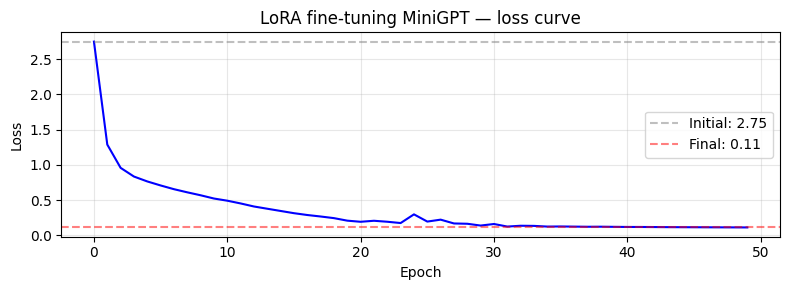

In [9]:
# ============================================================
#  Loss 
# ============================================================
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 3))
plt.plot(losses, 'b-', linewidth=1.5)
plt.axhline(y=losses[0], color='gray', linestyle='--', alpha=0.5, label=f'Initial: {losses[0]:.2f}')
plt.axhline(y=losses[-1], color='red', linestyle='--', alpha=0.5, label=f'Final: {losses[-1]:.2f}')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('LoRA fine-tuning MiniGPT — loss curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n ： 1% ,Loss ！")
print(" LoRA —— .")


### 8. Inference: merge weights, zero overhead

A neat trick: after training, you can precompute

`W_merged = W + (alpha/r) * A B`

Then inference is identical to the original model, with no extra compute.


In [10]:
# ============================================================
#  LoRA base weight
# ============================================================
def merge_lora(model):
    """ LoRA base weight,at inferencezero extra overhead"""
    for block in model.blocks:
        attn = block.attention
        for name in ['W_Q', 'W_V']:
            layer = getattr(attn, name)
            if isinstance(layer, LoraLinear):
                #  
                merged_weight = layer.linear.weight.data + layer.lora_A.data @ layer.lora_B.data * layer.scaling
                #  nn.Linear
                new_linear = nn.Linear(layer.in_features, layer.out_features, bias=False)
                new_linear.weight.data = merged_weight
                setattr(attn, name, new_linear)

#  
trainable_before = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f" : {trainable_before}")

merge_lora(model)

trainable_after = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f" : {trainable_after}")
print(f"\n , LoRA ！")

 : 93746
 : 106034

 , LoRA ！


### 9. Practical tips

| Question | Answer |
|:---|:---|
| Where to add LoRA? | most common: Q and V projections; also FFN / lm_head |
| Rank r? | r=8 or 16 is often enough; too small underfits, too big approaches full FT |
| alpha? | often 2-4×r; alpha/r is the effective scale |
| How many LoRAs per base model? | many; each LoRA is small and switchable |
| Quality gap vs full FT? | often small (<2%); on small data LoRA can overfit less |
| What is QLoRA? | LoRA + 4-bit quantization |

One-sentence summary: LoRA freezes the base model and trains two small matrices A and B on a side path. Training cost drops to ~1% while quality is similar, and you can merge weights for zero-overhead inference.
